## Lab 1: Data Generation and Visualization

These random datasets will be useful in later laboratories to test some of the algorithms seen in class.

Try to solve the following exercises using only the `numpy` and `matplotlib` python libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducible datasets

# Exercise 1: Gaussian
- Generate a dataset drawn from two independent Gaussians, each of which represents a class. You are free to select the number of desired datapoints, the mean and the variance of the two distributions.
- Flip randomly a percentage of the labels to introduce some noise and plot the results.

Given the binary classification setting we are considering, a flip implies that a point in class 0 will be assigned to class 1 and vice versa.

In [2]:
def mixGauss(means, sigmas, n):
    """
    Parameters:
    means: matrix/list of float of dimension n_classes x dim_data
        Means of the Gaussian functions
    sigmas: array/list of float of dimension n_classes
        Standard deviation of the Gaussian functions
    n: int
        Number of points for each class
    """
    means = np.array(means)
    sigmas = np.array(sigmas)

    dim = np.shape(means)[1]
    num_classes = sigmas.size

    data = np.full(fill_value=np.inf, shape=(n*num_classes, dim))
    labels = np.zeros(n*num_classes)

    for i, sigma in enumerate(sigmas):
        data[i*n:(i+1)*n] = np.random.multivariate_normal(mean=means[i], cov=np.eye(dim)*sigma**2, size=n)
        labels[i*n:(i+1)*n] = i

    return data, labels

In [3]:
means = [[3, 0], [0, 6]]  # (x1,y1), (x2,y2)
sigmas = [0.9, 0.9]       # (sigma1, sigma2)
n = 100

X, labels = mixGauss(means, sigmas, n)

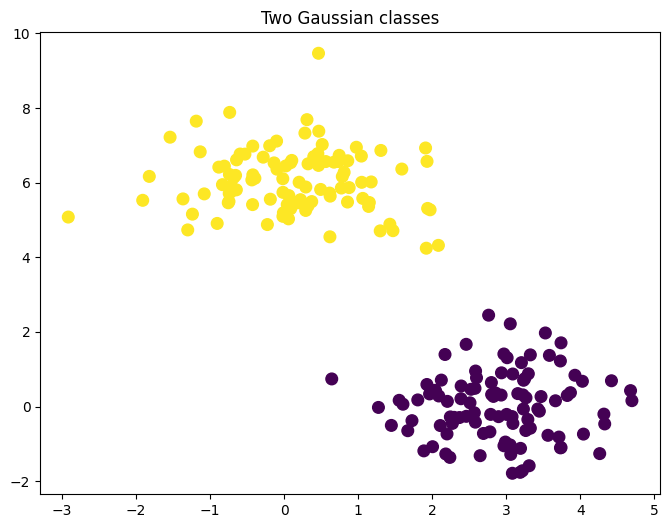

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=70, c=labels)
plt.title("Two Gaussian classes")
plt.show()

In [5]:
def labelsnoise(p, labels):
    """
    Parameters:
    p: float
        Fraction of labels to flip (e.g. 0.1 = 10%)
    labels: array of int of dimension n_points
        Array containing label indices (0 and 1)
    """
    n = np.shape(labels)[0]
    noisylabels = np.copy(np.squeeze(labels))

    n_flips = int(np.floor(n*p))
    idx_flip = np.random.choice(n, size=n_flips, replace=False)  # without replacement

    noisylabels[idx_flip] = 1 - noisylabels[idx_flip]  # labels are 0 and 1
    return noisylabels

In [6]:
noisy_labels = labelsnoise(0.1, labels)
print("flipped labels:", int((noisy_labels != labels).sum()), "out of", len(labels))

flipped labels: 20 out of 200


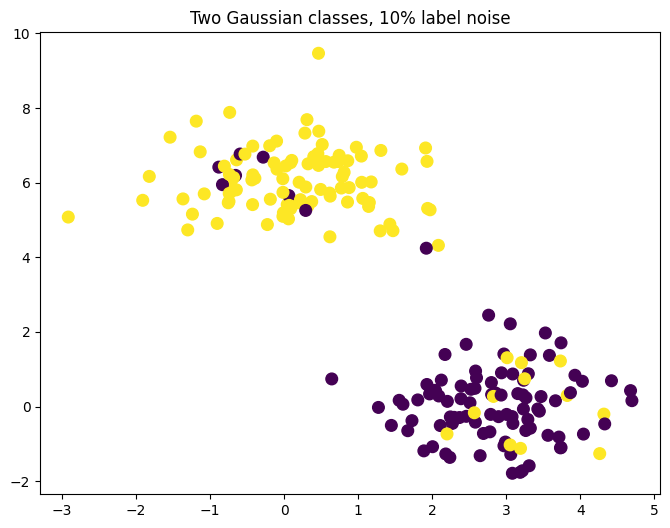

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=70, c=noisy_labels)
plt.title("Two Gaussian classes, 10% label noise")
plt.show()

The same idea works in higher dimensions: here we move to 3D.

In [8]:
means = [[3, 0, -2], [0, 6, 2]]
sigmas = [0.9, 0.9]
n = 1000

X, labels = mixGauss(means, sigmas, n)
noisy_labels = labelsnoise(0.1, labels)

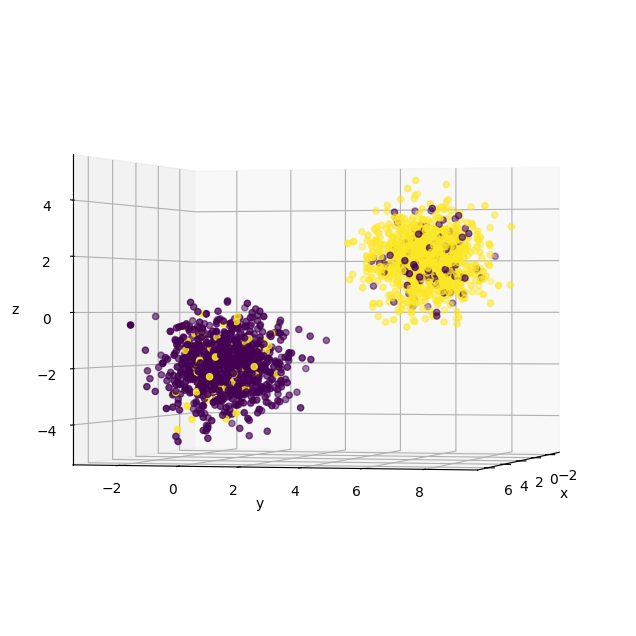

In [9]:
plt.figure(figsize=(10, 8))
axes = plt.axes(projection='3d')
axes.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=noisy_labels)

axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('z')
axes.view_init(0, 15)

plt.show()

## Exercise 2: Swiss roll
The Swiss Roll is defined by the following mapping:
$$x = \phi\cos(\phi) , \quad y= \phi\sin(\phi) , \quad z = \psi$$
with $\phi \in(1.5\pi, 4.5\pi)$ and $\psi \in(0,10)$

Create the dataset of $n=1000$ points and plot them both in 2d and 3d.

In [10]:
def swiss_roll(n):
    """
    Parameters:
    n: int
        Number of points to generate"""

    data = np.zeros((n, 3))
    phi = np.random.uniform(low=1.5*np.pi, high=4.5*np.pi, size=n)
    psi = np.random.uniform(0, 10, n)

    data[:, 0] = phi*np.cos(phi)  # x coordinate
    data[:, 1] = phi*np.sin(phi)  # y coordinate
    data[:, 2] = psi              # z coordinate
    return data, phi

In [11]:
X, phi = swiss_roll(1000)

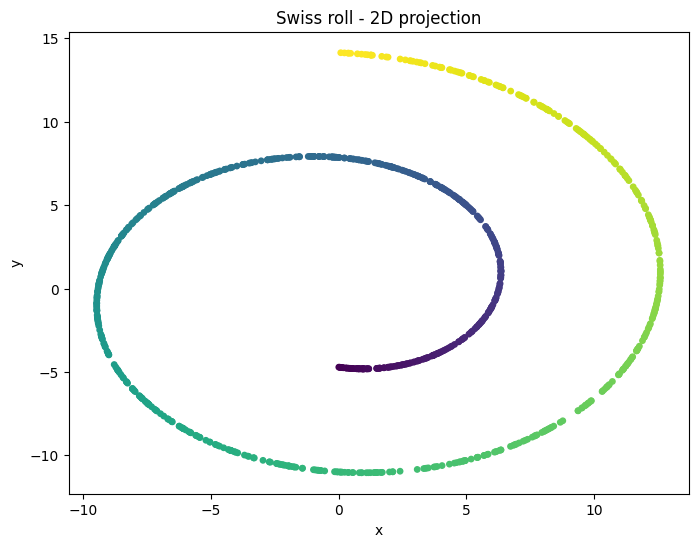

In [12]:
# 2D view: the (x, y) projection shows the spiral; colour = position along the roll
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=phi, s=15)
plt.xlabel('x'); plt.ylabel('y')
plt.title("Swiss roll - 2D projection")
plt.show()

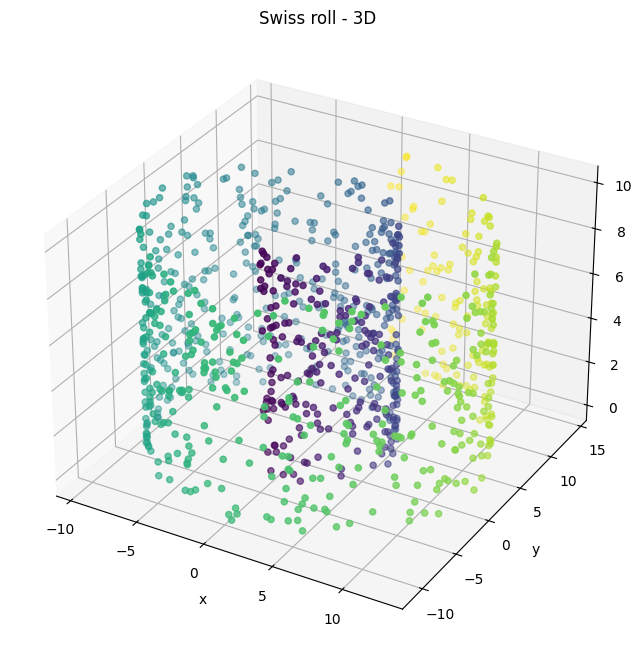

In [13]:
plt.figure(figsize=(10, 8))
axes = plt.axes(projection='3d')
axes.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=phi)

axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('z')
# axes.view_init(45, 45)  # (elevation, azimuth angle)
plt.title("Swiss roll - 3D")
plt.show()

## Exercise 3: Klein bottle
Find the equation describing the Klein bottle. Generate a dataset and plot it as in Exercise 2.

$$x = -\cfrac{2}{15}\cos u \left(3\cos v -30\sin u +90\cos^4 u\sin u -60\cos^6 u\sin u +5\cos u\cos v\sin u\right)$$
$$y = -\cfrac{1}{15}\sin u \left(3\cos v -3\cos^2 u\cos v -48\cos^4 u\cos v +48\cos^6 u\cos v-60\sin u +5\cos u\cos v\sin u -5\cos^3 u \cos v\sin u - 80 \cos^5 u \cos v\sin u +80\cos^7 u \cos v \sin u \right)$$
$$z = \cfrac{2}{15} \left(3 + 5\cos u \sin u \right)\sin v$$

with $0 \leq u < \pi$ and $0 \leq v < 2\pi$

In [14]:
def klein_bottle(n):
    """
    Parameters:
    n: int
        Number of points to generate"""

    u = np.random.uniform(low=0, high=np.pi, size=n)
    v = np.random.uniform(low=0, high=2*np.pi, size=n)
    cu, su, cv = np.cos(u), np.sin(u), np.cos(v)

    data = np.zeros((n, 3))
    data[:, 0] = -2/15*cu*(3*cv - 30*su + 90*cu**4*su - 60*cu**6*su + 5*cu*cv*su)
    data[:, 1] = -1/15*su*(3*cv - 3*cu**2*cv - 48*cu**4*cv + 48*cu**6*cv - 60*su
                           + 5*cu*cv*su - 5*cu**3*cv*su - 80*cu**5*cv*su + 80*cu**7*cv*su)
    data[:, 2] = 2/15*(3 + 5*cu*su)*np.sin(v)

    return data

In [15]:
X = klein_bottle(5000)

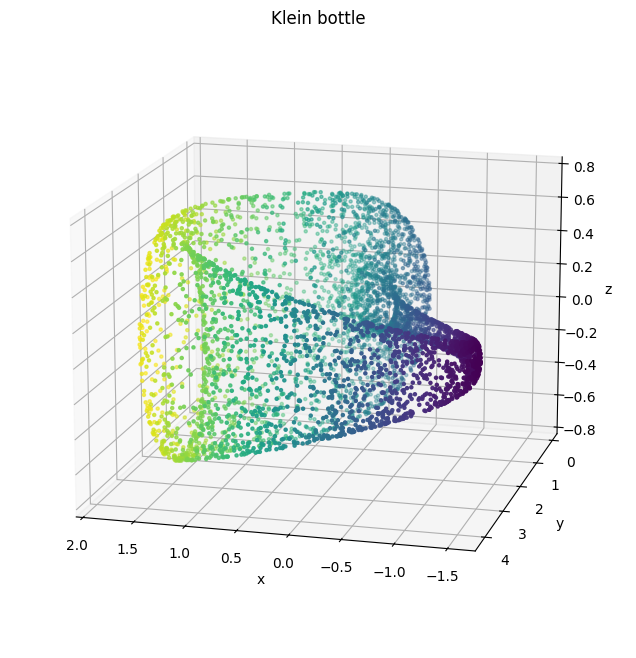

In [16]:
plt.figure(figsize=(10, 8))
axes = plt.axes(projection='3d')
axes.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=X[:, 0], s=5)

axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('z')
axes.view_init(15, 105)  # (elevation, azimuth angle)
plt.title("Klein bottle")
plt.show()

## Bonus with plotly

In [17]:
import plotly.express as px

In [18]:
fig = px.scatter_3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    color=X[:, 0],      # colour of the points
    opacity=0.7,        # transparency of the points
    title='Klein bottle (interactive)',
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(width=800, height=800)
fig.show()

In [19]:
means = [[3, 0, -2], [0, 6, 2]]
sigmas = [0.9, 0.9]
X, labels = mixGauss(means, sigmas, 1000)
noisy_labels = labelsnoise(0.1, labels)

fig = px.scatter_3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    color=noisy_labels.astype(str),  # discrete colours for the two classes
    opacity=0.7,
    title='Noisy Gaussians (interactive)',
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(width=800, height=800)
fig.show()